# Sprint 2 — Reference Parameter Extraction and LOBO Range Computation

Extracts 12 energy-relevant parameters from all 16 ASHRAE 90.1-2019 prototype
IDF files (Buffalo, CZ5A; PNNL-31488), computes Leave-One-Building-Out (LOBO)
reference ranges for the 9 LLM-target parameters of the 5 tested buildings,
and derives deterministic baselines against which the LLM's performance will
be evaluated in later sprints.

**Tested buildings (5):** OfficeMedium, SchoolPrimary, RetailStripmall,
ApartmentMidRise, RestaurantFastFood -- selected for building-type diversity
(office, education, retail, residential, food service) and under an a priori
rule requiring each building to have a comparable sibling remaining in the
pool for its most extreme parameter; see Limitations for how this rule
excluded a Warehouse-based alternative. RestaurantFastFood replaces
SmallOffice (used in a prior study) to increase occupancy/internal-load
diversity in the test set; fixed a priori, before any results were seen.

LOBO ranges are computed per tested building from the remaining pool (up to
n=15), excluding the building's own value. A buffer of 1/(n-1) of the raw
range **width** (not the value itself) is added to each side, correcting the
small-sample tendency to underestimate the true range; `buffer_sensitivity.csv`
reports how containment changes at 0%/7.1%/10%/15% of that width (42/45,
42/45, 43/45, 44/45 -- the pre-registered 7.1% buffer changes nothing over
the unbuffered case at this pool size).

**Three parameters are held fixed, not LLM targets:** infiltration, heating
efficiency, and roof U-value are **not** uniformly constant across the
16-building family (e.g. RestaurantFastFood's roof U-value differs from the
other four tested buildings: 0.122 vs 0.1864 W/m²K). They are held at each
building's own DOE-original value -- never a pooled constant -- are never
shown to the LLM in any prompt format, and are excluded from all GSO/PFI/
accuracy calculations. The study evaluates the LLM on the remaining
**9 target parameters** only. See `control_parameters.json`.

| # | Parameter | Role | IDF Object(s) | Field | Unit Conv. | Multi-Zone Method |
|---|---|---|---|---|---|---|
| 1 | window_u_value | target | WindowMaterial:SimpleGlazingSystem | U-Factor | direct SI | area-weighted mean over window surfaces |
| 2 | window_shgc | target | WindowMaterial:SimpleGlazingSystem | Solar Heat Gain Coefficient | direct SI | area-weighted mean over window surfaces |
| 3 | lighting_W_m2 | target | Lights | Watts/Area or Level÷zone area | direct/derived | area-weighted mean |
| 4 | equipment_W_m2 | target | ElectricEquipment | Watts/Area or Level÷zone area | direct/derived | area-weighted mean, excl. non-occupiable zones |
| 5 | occupancy_m2_person | target | People | Area/Person, People/Area, or Area÷count | direct/derived | area-weighted mean |
| 6 | infiltration | **control** | ZoneInfiltration:DesignFlowRate | Flow Rate per Ext. Wall Area | direct SI | mean, Flow/Zone excluded |
| 7 | outdoor_air | target | DesignSpecification:OutdoorAir | Flow per Area / per Person | direct/derived | zone-area-weighted mean via Sizing:Zone lookup, Sum/Max method-aware |
| 8 | cooling_cop | target | Coil:Cooling:DX:*; Chiller:Electric:(Reformulated)EIR; Coil:Cooling:WaterToAirHeatPump | Gross/Reference COP | direct SI | capacity-weighted mean |
| 9 | heating_efficiency | **control** | Coil:Heating:Fuel/Gas; Boiler:HotWater; Coil:Heating:Electric | Burner/Thermal Efficiency | direct SI | capacity-weighted mean |
| 10 | heating_setpoint_C | target | ThermostatSetpoint:DualSetpoint → Schedule:Compact | Heating schedule value | direct SI | median per thermostat, mean across |
| 11 | cooling_setpoint_C | target | ThermostatSetpoint:DualSetpoint → Schedule:Compact | Cooling schedule value | direct SI | median per thermostat, mean across |
| 12 | roof_u_value | **control** | BuildingSurface:Detailed → Construction → Material(:NoMass/:AirGap) | Thermal Resistance (summed) | U = 1/R | most-insulated candidate selected |

In [1]:
# S2-0  Setup
from google.colab import drive
drive.mount('/content/drive')

import os, re, json
import numpy as np
import pandas as pd
from collections import defaultdict

BASE   = '/content/drive/MyDrive/BEM-LLM'
DATA   = f'{BASE}/data'
REF    = f'{DATA}/idf_referans'
ANALIZ = f'{BASE}/analiz/sprint2_lobo'
os.makedirs(ANALIZ, exist_ok=True)

with open(f'{DATA}/environment_sprint1.json') as f:
    MASTER_SEED = json.load(f)['master_seed']

TESTED_BUILDINGS = [
    'OfficeMedium', 'SchoolPrimary', 'RetailStripmall',
    'ApartmentMidRise', 'RestaurantFastFood',
]
POOL_BUILDINGS = [
    'ApartmentHighRise', 'Hospital', 'HotelLarge', 'HotelSmall', 'OfficeLarge',
    'OfficeSmall', 'OutPatientHealthCare', 'RestaurantSitDown',
    'RetailStandalone', 'SchoolSecondary', 'Warehouse',
]
ALL_BUILDINGS = TESTED_BUILDINGS + POOL_BUILDINGS

def idf_path(name):
    return f'{REF}/ASHRAE901_{name}_STD2019_Buffalo.idf'

missing = [b for b in ALL_BUILDINGS if not os.path.exists(idf_path(b))]
assert not missing, f'Missing IDF files: {missing}'
print(f'IDF files verified: {len(ALL_BUILDINGS)}/{len(ALL_BUILDINGS)}')

Mounted at /content/drive
IDF files verified: 16/16


In [2]:
# S2-A  Parser and utilities
_WEIGHT_FALLBACK_LOG = defaultdict(int)

def parse_idf(path):
    """Parse an IDF file into {OBJECT_TYPE: [field_list, ...]}."""
    with open(path, 'r', errors='ignore') as f:
        content = f.read()
    content = re.sub(r'!.*', '', content)
    content = re.sub(r'\r\n|\r', '\n', content)
    objects = defaultdict(list)
    for block in re.split(r';\s*\n', content):
        block = block.strip()
        if not block:
            continue
        fields = [f.strip() for f in block.split(',')]
        key = fields[0].upper().strip()
        if key:
            objects[key].append(fields[1:])
    return dict(objects)


def safe_float(val):
    """Cast to float; returns None for invalid or non-finite values."""
    try:
        v = float(str(val).strip())
        return v if np.isfinite(v) else None
    except Exception:
        return None


def weighted_mean(vals, weights=None):
    """Weighted mean over non-null values; falls back to an unweighted mean."""
    vals = [v for v in vals if v is not None]
    if not vals:
        return None
    if weights is None:
        return float(np.mean(vals))
    wts = [w for v, w in zip(vals, weights) if v is not None]
    total = sum(wts)
    return float(sum(v * w for v, w in zip(vals, wts)) / total) if total else float(np.mean(vals))


def get_zone_floor_area(obj, zone_name):
    """Zone floor area [m2] via the shoelace formula on BuildingSurface:Detailed floor vertices."""
    if not zone_name:
        return None
    zone_up = zone_name.strip().upper()
    total = 0.0
    for surf in obj.get('BUILDINGSURFACE:DETAILED', []):
        if len(surf) < 12 or surf[1].strip().lower() != 'floor':
            continue
        if surf[3].strip().upper() != zone_up:
            continue
        try:
            n = int(float(surf[10]))
        except Exception:
            n = (len(surf) - 11) // 3
        coords = []
        for i in range(n):
            idx = 11 + i * 3
            if idx + 1 >= len(surf):
                break
            try:
                coords.append((float(surf[idx]), float(surf[idx + 1])))
            except Exception:
                pass
        if len(coords) >= 3:
            n2 = len(coords)
            total += 0.5 * abs(sum(
                coords[i][0] * coords[(i + 1) % n2][1] -
                coords[(i + 1) % n2][0] * coords[i][1]
                for i in range(n2)))
    return total if total > 0 else None

In [3]:
# S2-B1  Envelope and internal-load extractors.
def polygon_area_3d(vertices):
    """Planar-polygon area via Newell's method; valid for tilted/vertical surfaces."""
    normal = np.zeros(3)
    n = len(vertices)
    for i in range(n):
        v1, v2 = np.array(vertices[i]), np.array(vertices[(i + 1) % n])
        normal += np.cross(v1, v2)
    return float(np.linalg.norm(normal)) / 2.0


def get_fenestration_area(fs):
    """fs[7]=Multiplier, fs[8]=Number of Vertices, fs[9:]=vertices (IDD sırası)."""
    try:
        n_vertices = int(float(fs[8]))
    except (ValueError, IndexError):
        return None
    coords = fs[9:9 + n_vertices * 3]
    if len(coords) < n_vertices * 3:
        return None
    vertices = []
    for i in range(n_vertices):
        x, y, z = safe_float(coords[i * 3]), safe_float(coords[i * 3 + 1]), safe_float(coords[i * 3 + 2])
        if None in (x, y, z):
            return None
        vertices.append((x, y, z))
    return polygon_area_3d(vertices) if len(vertices) >= 3 else None


def get_window_u_shgc(obj):
    """Area-weighted mean window U-value and SHGC via Construction -> WindowMaterial:SimpleGlazingSystem."""
    con_to_glazing = {}
    for con in obj.get('CONSTRUCTION', []):
        if con and (layers := [l.strip().upper() for l in con[1:] if l.strip()]):
            con_to_glazing[con[0].strip().upper()] = layers[0]

    glazing_props = {}
    for wm in obj.get('WINDOWMATERIAL:SIMPLEGLAZINGSYSTEM', []):
        if len(wm) < 3:
            continue
        u, shgc = safe_float(wm[1]), safe_float(wm[2])
        if u and shgc:
            glazing_props[wm[0].strip().upper()] = (u, shgc)

    us, shgcs, areas = [], [], []
    for fs in obj.get('FENESTRATIONSURFACE:DETAILED', []):
        if len(fs) < 3 or fs[1].strip().lower() != 'window':
            continue
        props = glazing_props.get(con_to_glazing.get(fs[2].strip().upper()))
        if not props:
            continue
        area = get_fenestration_area(fs)
        if not area or area <= 0:
            area = 1.0
            _WEIGHT_FALLBACK_LOG['get_window_u_shgc'] += 1
        us.append(props[0]); shgcs.append(props[1]); areas.append(area)

    if not us:
        return None, None
    return round(weighted_mean(us, areas), 4), round(weighted_mean(shgcs, areas), 4)


def get_lighting(obj):
    """Area-weighted lighting power density [W/m2]."""
    vals, areas = [], []
    for lt in obj.get('LIGHTS', []):
        if len(lt) < 5:
            continue
        method, zone_name = lt[3].strip(), lt[1].strip().upper()
        zone_area = get_zone_floor_area(obj, zone_name)
        if 'Watts/Area' in method:
            v = safe_float(lt[5]) if len(lt) > 5 else None
            if v and v > 0:
                vals.append(v)
                areas.append(zone_area if zone_area else 1.0)
                if not zone_area:
                    _WEIGHT_FALLBACK_LOG['get_lighting'] += 1
        elif 'LightingLevel' in method or 'Watts/Zone' in method:
            total_w = safe_float(lt[4]) if len(lt) > 4 else None
            if total_w and zone_area:
                vals.append(total_w / zone_area); areas.append(zone_area)
    return round(weighted_mean(vals, areas), 3) if vals else None


def get_equipment(obj, building_name=None):
    """Area-weighted equipment power density [W/m2]; excludes non-occupiable zones and >150 W/m2 process loads."""
    EXCLUDE = ['CORRIDOR', 'MECH', 'BATH', 'LOBBY', 'STAIR', 'PLENUM', 'JANITOR']
    if building_name != 'Warehouse':
        EXCLUDE.append('STORAGE')

    vals, areas = [], []
    for eq in obj.get('ELECTRICEQUIPMENT', []):
        if len(eq) < 4:
            continue
        method, zone_name = eq[3].strip(), eq[1].strip().upper()
        zone_area = get_zone_floor_area(obj, zone_name)
        if 'Watts/Area' in method:
            v = safe_float(eq[5]) if len(eq) > 5 else None
            if v and v > 0:
                vals.append(v)
                areas.append(zone_area if zone_area else 1.0)
                if not zone_area:
                    _WEIGHT_FALLBACK_LOG['get_equipment'] += 1
        elif 'EquipmentLevel' in method and not any(kw in zone_name for kw in EXCLUDE):
            total_w = safe_float(eq[4]) if len(eq) > 4 else None
            if total_w and zone_area:
                density = total_w / zone_area
                if density <= 150.0:
                    vals.append(density); areas.append(zone_area)
    return round(weighted_mean(vals, areas), 3) if vals else None


def get_occupancy(obj):
    """Area-weighted occupant density [m2/person]."""
    vals, areas = [], []
    for pe in obj.get('PEOPLE', []):
        if len(pe) < 4:
            continue
        zone_name, method = pe[1].strip().upper(), pe[3].strip()
        zone_area = get_zone_floor_area(obj, zone_name)
        if 'Area/Person' in method:
            v = safe_float(pe[6]) if len(pe) > 6 else None
            if v and v > 0:
                vals.append(v)
                areas.append(zone_area if zone_area else 1.0)
                if not zone_area:
                    _WEIGHT_FALLBACK_LOG['get_occupancy'] += 1
        elif 'People/Area' in method:
            v = safe_float(pe[5]) if len(pe) > 5 else None
            if v and v > 0:
                vals.append(1.0 / v)
                areas.append(zone_area if zone_area else 1.0)
                if not zone_area:
                    _WEIGHT_FALLBACK_LOG['get_occupancy'] += 1
        elif method == 'People':
            n_ppl = safe_float(pe[4]) if len(pe) > 4 else None
            if n_ppl and zone_area:
                vals.append(zone_area / n_ppl); areas.append(zone_area)
    return round(weighted_mean(vals, areas), 3) if vals else None


def get_infiltration(obj):
    """Mean infiltration flow rate per exterior wall area [m3/s-m2]; Flow/Zone entries excluded."""
    vals = []
    for inf in obj.get('ZONEINFILTRATION:DESIGNFLOWRATE', []):
        if len(inf) < 7:
            continue
        if 'ExteriorWallArea' in inf[3] or 'ExteriorArea' in inf[3]:
            v = safe_float(inf[6])
            if v and v > 0:
                vals.append(v)
    return round(float(np.mean(vals)), 6) if vals else None


def _build_oa_spec_zone_map(obj):
    """Map DesignSpecification:OutdoorAir name to zone name, via Sizing:Zone."""
    spec_to_zone = {}
    for sz in obj.get('SIZING:ZONE', []):
        if len(sz) > 9 and sz[0].strip() and sz[9].strip():
            spec_to_zone[sz[9].strip().upper()] = sz[0].strip().upper()
    return spec_to_zone


def _zone_occupancy_density(obj, zone_name):
    """Occupant density [m2/person] for a single zone, mirroring get_occupancy's branch logic."""
    if not zone_name:
        return None
    zone_up = zone_name.strip().upper()
    for pe in obj.get('PEOPLE', []):
        if len(pe) < 4 or pe[1].strip().upper() != zone_up:
            continue
        method = pe[3].strip()
        if 'Area/Person' in method:
            v = safe_float(pe[6]) if len(pe) > 6 else None
            if v and v > 0:
                return v
        elif 'People/Area' in method:
            v = safe_float(pe[5]) if len(pe) > 5 else None
            if v and v > 0:
                return 1.0 / v
        elif method == 'People':
            n_ppl = safe_float(pe[4]) if len(pe) > 4 else None
            zone_area = get_zone_floor_area(obj, zone_name)
            if n_ppl and zone_area:
                return zone_area / n_ppl
    return None


def get_outdoor_air(obj):
    """Zone-area-weighted outdoor air flow [m3/s-m2]; Flow/Person, Flow/Area, and Flow/Zone
    components are combined per the DesignSpecification:OutdoorAir calculation method."""
    building_occ = get_occupancy(obj) or 18.0
    spec_to_zone = _build_oa_spec_zone_map(obj)
    vals, weights = [], []

    for spec in obj.get('DESIGNSPECIFICATION:OUTDOORAIR', []):
        if len(spec) < 2:
            continue
        spec_name = spec[0].strip().upper() if spec[0].strip() else None
        method = spec[1].strip()
        fp = safe_float(spec[2]) if len(spec) > 2 else 0.0
        fa = safe_float(spec[3]) if len(spec) > 3 else 0.0
        fz = safe_float(spec[4]) if len(spec) > 4 else 0.0
        fp, fa, fz = fp or 0.0, fa or 0.0, fz or 0.0

        zone_name = spec_to_zone.get(spec_name) if spec_name else None
        zone_area = get_zone_floor_area(obj, zone_name) if zone_name else None
        zone_occ = _zone_occupancy_density(obj, zone_name) if zone_name else None
        occ = zone_occ or building_occ

        fp_area = fp / occ if occ > 0 else 0.0
        fz_area = fz / zone_area if zone_area else 0.0

        combined_val = {'Sum': fp_area + fa + fz_area,
                        'Maximum': max(fp_area, fa, fz_area),
                        'Flow/Area': fa, 'Flow/Person': fp_area}.get(
                            next((k for k in ('Sum', 'Maximum', 'Flow/Area', 'Flow/Person') if k in method), None),
                            fp_area + fa + fz_area)
        if combined_val <= 0:
            continue
        vals.append(combined_val)
        weights.append(zone_area if zone_area else 1.0)
        if not zone_area:
            _WEIGHT_FALLBACK_LOG['get_outdoor_air'] += 1

    return round(weighted_mean(vals, weights), 6) if vals else None

In [4]:
# S2-B2  Extraction functions: HVAC efficiency and roof U-value
def get_cooling_cop(obj):
    """Capacity-weighted cooling COP across DX coils, chillers, and water-to-air heat pumps."""
    cop_vals, cap_wts = [], []

    for coil in obj.get('COIL:COOLING:DX:SINGLESPEED', []) + obj.get('COIL:COOLING:DX:TWOSPEED', []):
        cop = safe_float(coil[4]) if len(coil) > 4 else None
        cap = safe_float(coil[3]) if len(coil) > 3 else None
        if cop and 1.5 < cop < 8.0:
            cop_vals.append(cop); cap_wts.append(cap or 1.0)

    for coil in obj.get('COIL:COOLING:DX:MULTISPEED', []):
        n_std = safe_float(coil[17]) if len(coil) > 17 else None
        found = False
        if n_std and 1 <= n_std <= 10:
            for k in range(int(n_std)):
                base = 18 + k * 17
                cap = safe_float(coil[base]) if len(coil) > base else None
                cop = safe_float(coil[base + 2]) if len(coil) > base + 2 else None
                if cop and 1.5 < cop < 8.0:
                    cop_vals.append(cop); cap_wts.append(cap or 1.0); found = True
        if not found:
            n_psz = safe_float(coil[18]) if len(coil) > 18 else None
            if n_psz and 1 <= n_psz <= 10:
                for k in range(int(n_psz)):
                    base = 19 + k * 20
                    cap = safe_float(coil[base]) if len(coil) > base else None
                    cop = safe_float(coil[base + 2]) if len(coil) > base + 2 else None
                    if cop and 1.5 < cop < 8.0:
                        cop_vals.append(cop); cap_wts.append(cap or 1.0)

    for ch in obj.get('CHILLER:ELECTRIC:EIR', []):
        cop = safe_float(ch[3]) if len(ch) > 3 else None
        cap = safe_float(ch[1]) if len(ch) > 1 else None
        if cop and 1.5 < cop < 12.0:
            cop_vals.append(cop); cap_wts.append(cap or 1.0)

    for ch in obj.get('CHILLER:ELECTRIC:REFORMULATEDEIR', []):
        cap = safe_float(ch[1]) if len(ch) > 1 else None
        cop = safe_float(ch[2]) if len(ch) > 2 else None
        if cop and 1.5 < cop < 12.0:
            cop_vals.append(cop); cap_wts.append(cap or 1.0)

    for coil in obj.get('COIL:COOLING:WATERTOAIRHEATPUMP:EQUATIONFIT', []):
        cap = safe_float(coil[7]) if len(coil) > 7 else None
        cop = safe_float(coil[9]) if len(coil) > 9 else None
        if cop and 1.5 < cop < 8.0:
            cop_vals.append(cop); cap_wts.append(cap or 1.0)

    return round(weighted_mean(cop_vals, cap_wts), 3) if cop_vals else None


def get_heating_efficiency(obj):
    """Capacity-weighted heating thermal efficiency; Coil:Heating:Electric assumed 1.0."""
    vals, wts = [], []
    for c in obj.get('COIL:HEATING:FUEL', []):
        e, cap = (safe_float(c[3]) if len(c) > 3 else None), (safe_float(c[4]) if len(c) > 4 else None)
        if e and 0.5 < e <= 1.0:
            vals.append(e); wts.append(cap or 1.0)
    for c in obj.get('COIL:HEATING:GAS', []):
        e, cap = (safe_float(c[2]) if len(c) > 2 else None), (safe_float(c[3]) if len(c) > 3 else None)
        if e and 0.5 < e <= 1.0:
            vals.append(e); wts.append(cap or 1.0)
    for b in obj.get('BOILER:HOTWATER', []):
        e, cap = (safe_float(b[3]) if len(b) > 3 else None), (safe_float(b[2]) if len(b) > 2 else None)
        if e and 0.5 < e <= 1.0:
            vals.append(e); wts.append(cap or 1.0)
    if not vals and obj.get('COIL:HEATING:ELECTRIC'):
        n = len(obj['COIL:HEATING:ELECTRIC'])
        vals, wts = [1.0] * n, [1.0] * n
    return round(weighted_mean(vals, wts), 3) if vals else None


def get_setpoints(obj):
    """Occupied heating/cooling setpoints [C]; range filters exclude setback values."""
    sched_vals = {}
    for sched in obj.get('SCHEDULE:COMPACT', []):
        if not sched:
            continue
        values = [v for f in sched[2:] if not f.strip().lower().startswith(
            ('through', 'for', 'until', 'interpolate')) and (v := safe_float(f.strip())) is not None]
        if values:
            sched_vals[sched[0].strip().upper()] = values

    heat_vals, cool_vals = [], []
    for tstat in obj.get('THERMOSTATSETPOINT:DUALSETPOINT', []):
        if len(tstat) < 3:
            continue
        h = [v for v in sched_vals.get(tstat[1].strip().upper(), []) if 18.0 <= v <= 26.0]
        c = [v for v in sched_vals.get(tstat[2].strip().upper(), []) if 20.0 <= v <= 27.0]
        if h:
            heat_vals.append(float(np.median(h)))
        if c:
            cool_vals.append(float(np.median(c)))

    heat_sp = round(float(np.mean(heat_vals)), 2) if heat_vals else None
    cool_sp = round(float(np.mean(cool_vals)), 2) if cool_vals else None
    return heat_sp, cool_sp


def get_roof_u(obj):
    """Roof U-value [W/m2K] via BuildingSurface:Detailed(roof/ceiling) -> Construction -> Material chain."""
    mat_r = {}
    for m in obj.get('MATERIAL', []):
        if len(m) < 4:
            continue
        thick, cond = safe_float(m[2]), safe_float(m[3])
        if thick and cond:
            mat_r[m[0].strip().upper()] = thick / cond
    for m in obj.get('MATERIAL:NOMASS', []):
        if len(m) >= 3 and (r := safe_float(m[2])):
            mat_r[m[0].strip().upper()] = r
    for m in obj.get('MATERIAL:AIRGAP', []):
        if len(m) >= 2 and (r := safe_float(m[1])):
            mat_r[m[0].strip().upper()] = r

    con_r = {}
    for con in obj.get('CONSTRUCTION', []):
        if con:
            r_total = sum(mat_r.get(l.strip().upper(), 0) for l in con[1:] if l.strip())
            if r_total > 0:
                con_r[con[0].strip().upper()] = r_total

    roof_cons = {surf[2].strip().upper() for surf in obj.get('BUILDINGSURFACE:DETAILED', [])
                 if len(surf) >= 3 and surf[1].strip().lower() in ('roof', 'ceiling')}
    candidates = {c: r for c, r in con_r.items() if c in roof_cons}
    return round(1.0 / max(candidates.values()), 4) if candidates else None

In [5]:
# S2-C  Main extraction run (all 16 buildings, single pass)
PARAM_COLS = ['window_u_value', 'window_shgc', 'lighting_W_m2', 'equipment_W_m2',
              'occupancy_m2_person', 'infiltration', 'outdoor_air', 'cooling_cop',
              'heating_efficiency', 'heating_setpoint_C', 'cooling_setpoint_C', 'roof_u_value']

_WEIGHT_FALLBACK_LOG.clear()
rows = []
for bldg in ALL_BUILDINGS:
    obj = parse_idf(idf_path(bldg))
    u, shgc = get_window_u_shgc(obj)
    h_sp, c_sp = get_setpoints(obj)
    rows.append({'building_type': bldg, 'window_u_value': u, 'window_shgc': shgc,
                 'lighting_W_m2': get_lighting(obj), 'equipment_W_m2': get_equipment(obj, bldg),
                 'occupancy_m2_person': get_occupancy(obj), 'infiltration': get_infiltration(obj),
                 'outdoor_air': get_outdoor_air(obj), 'cooling_cop': get_cooling_cop(obj),
                 'heating_efficiency': get_heating_efficiency(obj), 'heating_setpoint_C': h_sp,
                 'cooling_setpoint_C': c_sp, 'roof_u_value': get_roof_u(obj),
                 'zone_count': len(obj.get('ZONE', []))})

all_df = pd.DataFrame(rows).set_index('building_type')
n_missing = int(all_df[PARAM_COLS].isna().sum().sum())
print(f'Extraction complete: {len(all_df) * len(PARAM_COLS) - n_missing}/'
      f'{len(all_df) * len(PARAM_COLS)} values populated ({n_missing} missing).')
print('Area-weighting fallbacks:', dict(_WEIGHT_FALLBACK_LOG) if _WEIGHT_FALLBACK_LOG else 'none')

df = all_df.loc[all_df.index.isin(TESTED_BUILDINGS)].copy()
pool_df = all_df.loc[all_df.index.isin(POOL_BUILDINGS)].copy()
df.to_csv(f'{ANALIZ}/reference_parameters.csv', float_format='%.6g')
pool_df.to_csv(f'{ANALIZ}/pool_parameters.csv', float_format='%.6g')
print(f'Saved: reference_parameters.csv ({len(df)} buildings), pool_parameters.csv ({len(pool_df)} buildings)')

Extraction complete: 192/192 values populated (0 missing).
Area-weighting fallbacks: none
Saved: reference_parameters.csv (5 buildings), pool_parameters.csv (11 buildings)


In [6]:
# S2-C2  Manual cross-validation (3 pool buildings)
COP_OBJECT_TYPES = ['COIL:COOLING:DX:SINGLESPEED', 'COIL:COOLING:DX:TWOSPEED',
                    'COIL:COOLING:DX:MULTISPEED', 'CHILLER:ELECTRIC:EIR',
                    'CHILLER:ELECTRIC:REFORMULATEDEIR', 'COIL:COOLING:WATERTOAIRHEATPUMP:EQUATIONFIT']
CROSSCHECK_BUILDINGS = ['Hospital', 'HotelLarge', 'Warehouse']

crosscheck_rows = []
for bldg in CROSSCHECK_BUILDINGS:
    obj = parse_idf(idf_path(bldg))
    crosscheck_rows += [
        {'building': bldg, 'parameter': 'equipment_W_m2', 'pipeline_value': get_equipment(obj, bldg),
         'n_objects': len(obj.get('ELECTRICEQUIPMENT', []))},
        {'building': bldg, 'parameter': 'occupancy_m2_person', 'pipeline_value': get_occupancy(obj),
         'n_objects': len(obj.get('PEOPLE', []))},
        {'building': bldg, 'parameter': 'cooling_cop', 'pipeline_value': get_cooling_cop(obj),
         'n_objects': sum(len(obj.get(k, [])) for k in COP_OBJECT_TYPES)},
    ]

crosscheck_df = pd.DataFrame(crosscheck_rows)
crosscheck_df.to_csv(f'{ANALIZ}/pool_crosscheck.csv', index=False)
print(crosscheck_df.to_string(index=False))
print(f'Saved: {ANALIZ}/pool_crosscheck.csv')

  building           parameter  pipeline_value  n_objects
  Hospital      equipment_W_m2          23.706         50
  Hospital occupancy_m2_person          52.687         55
  Hospital         cooling_cop           5.418          3
HotelLarge      equipment_W_m2          18.443         22
HotelLarge occupancy_m2_person          13.853         22
HotelLarge         cooling_cop           6.670          1
 Warehouse      equipment_W_m2           2.938          2
 Warehouse occupancy_m2_person          43.025          3
 Warehouse         cooling_cop           3.835          2
Saved: /content/drive/MyDrive/BEM-LLM/analiz/sprint2_lobo/pool_crosscheck.csv


In [7]:
#S2-D — Parameter-to-object mapping table
mapping_rows = [
    ('window_u_value', 'WindowMaterial:SimpleGlazingSystem', 'U-Factor', 'direct SI (W/m2K)',
     'Mean across window fenestration surfaces, resolved via Construction lookup'),
    ('window_shgc', 'WindowMaterial:SimpleGlazingSystem', 'Solar Heat Gain Coefficient', 'direct SI (-)',
     'Mean across window fenestration surfaces'),
    ('lighting_W_m2', 'Lights', 'Watts per Zone Floor Area (or Lighting Level / zone area)',
     'direct SI or derived (W/m2)', 'Area-weighted mean across zones'),
    ('equipment_W_m2', 'ElectricEquipment', 'Watts per Zone Floor Area (or Design Level / zone area)',
     'direct SI or derived (W/m2)', 'Area-weighted mean; non-occupiable zones excluded'),
    ('occupancy_m2_person', 'People', 'Area/Person, People/Area, or Area / people count',
     'direct SI or derived (m2/person)', 'Area-weighted mean across zones'),
    ('infiltration', 'ZoneInfiltration:DesignFlowRate', 'Flow Rate per Exterior Wall Area',
     'direct SI (m3/s-m2)', 'Mean across Flow/ExteriorWallArea entries; Flow/Zone excluded'),
    ('outdoor_air', 'DesignSpecification:OutdoorAir', 'Flow per Area / per Person / per Zone',
     'direct SI or derived via zone occupancy (m3/s-m2)', 'Zone-area-weighted mean, method-aware'),
    ('cooling_cop', 'Coil:Cooling:DX:*; Chiller:Electric:(Reformulated)EIR; Coil:Cooling:WaterToAirHeatPump',
     'Gross/Reference Cooling COP', 'direct SI (W/W)', 'Capacity-weighted mean'),
    ('heating_efficiency', 'Coil:Heating:Fuel/Gas; Boiler:HotWater; Coil:Heating:Electric',
     'Burner/Thermal Efficiency (Electric = 1.0)', 'direct SI (-)', 'Capacity-weighted mean'),
    ('heating_setpoint_C', 'ThermostatSetpoint:DualSetpoint -> Schedule:Compact', 'Heating schedule value',
     'direct SI (C)', 'Median of occupied-range values per thermostat, mean across thermostats'),
    ('cooling_setpoint_C', 'ThermostatSetpoint:DualSetpoint -> Schedule:Compact', 'Cooling schedule value',
     'direct SI (C)', 'Median of occupied-range values per thermostat, mean across thermostats'),
    ('roof_u_value', 'BuildingSurface:Detailed (roof/ceiling) -> Construction -> Material/:NoMass/:AirGap',
     'Thermal Resistance (summed across layers)', 'derived: U = 1/R_total',
     'Most-insulated candidate construction selected'),
]
mapping_df = pd.DataFrame(mapping_rows, columns=['parameter', 'idf_object', 'field', 'unit_conversion', 'multi_zone_method'])
mapping_df.to_csv(f'{ANALIZ}/parameter_object_mapping.csv', index=False)
print(f'Saved: {ANALIZ}/parameter_object_mapping.csv ({len(mapping_df)} parameters)')

Saved: /content/drive/MyDrive/BEM-LLM/analiz/sprint2_lobo/parameter_object_mapping.csv (12 parameters)


## LOBO Range Computation, Baselines, and Leakage Safeguards

**Formula:**

$$R_{-b} = \max(P_{-b}) - \min(P_{-b})$$
$$L_b = \max\big(\text{physical\_min},\ \min(P_{-b}) - \tfrac{1}{n-1} R_{-b}\big)$$
$$U_b = \min\big(\text{physical\_max},\ \max(P_{-b}) + \tfrac{1}{n-1} R_{-b}\big)$$

$\frac{1}{n-1}$ is a fraction of the raw range **width**, not a percentage of
the value itself -- it corrects the small-sample bias whereby $R_{-b}$
underestimates the true population range ($E[R_{-b}] = \frac{n-1}{n+1}
\cdot \text{true range}$). For $n=15$ this equals $\approx 7.1\%$ of the
width added to each side. `buffer_sensitivity.csv` shows this barely moves
containment at this pool size: 0% and 7.1% both give 42/45 (93.3%)
identically; 10% reaches 43/45 (95.6%), 15% reaches 44/45 (97.8%). The
pre-registered 1/(n-1) rule is used in the main experiment regardless;
this is reported as a sensitivity check, not a change of method.

Physical bounds applied after buffering: SHGC $[0,1]$; COP and U-values
non-negative; flow rates and power densities non-negative; threshold
temperatures within a plausible HVAC range (10-30°C heating, 15-35°C
cooling). These bounds apply to the 9 target parameters only -- the 3
control parameters (infiltration, heating efficiency, roof U-value) are
never ranged or bounded; they are DOE-original, per-building constants
(`control_parameters.json`).

**Coverage:** at the 5-tested-building level, 42/45 (93.3%) checks fall
inside their own LOBO range; the 3 misses are SchoolPrimary/cooling_setpoint_C,
RestaurantFastFood/equipment_W_m2, and RestaurantFastFood/outdoor_air.
Extending the leave-one-out check to the full 16-building pool gives a
consistent 134/144 (93.1%), with 10 misses spread across 8 buildings and
7 parameters (`full_pool_loo_audit.csv`) -- no single parameter or building
dominates the shortfall. These misses are reported as a finding about
out-of-distribution generalization difficulty, not treated as a pipeline
failure or used to adjust the ranges after the fact.

**Leakage safeguards:** a building's own value is never used to compute
its own range. The global constant baseline is computed from the 11 pool
buildings only, with zero exposure to any tested building. Ranges are
never adjusted after the fact to force containment of the reference value.

In [8]:
#S2-E — Target/control split and LOBO range computation
CONTROL_PARAMETERS = ['infiltration', 'heating_efficiency', 'roof_u_value']
VARYING_PARAMS = ['window_u_value', 'window_shgc', 'lighting_W_m2', 'equipment_W_m2',
                  'occupancy_m2_person', 'outdoor_air', 'cooling_cop',
                  'heating_setpoint_C', 'cooling_setpoint_C']

control_values = {b: {p: df.loc[b, p] for p in CONTROL_PARAMETERS} for b in TESTED_BUILDINGS}
with open(f'{ANALIZ}/control_parameters.json', 'w') as f:
    json.dump({
        'description': ('DOE prototype original values, held fixed at the IDF value, never '
                         'presented to the LLM, and excluded from all accuracy calculations.'),
        'parameters': CONTROL_PARAMETERS,
        'values_by_building': control_values,
    }, f, indent=2, default=str)
print(f'Saved: control_parameters.json ({len(CONTROL_PARAMETERS)} parameters, {len(TESTED_BUILDINGS)} buildings)')

PHYSICAL_BOUNDS = {
    'window_u_value': (0.0, None), 'window_shgc': (0.0, 1.0),
    'lighting_W_m2': (0.0, None), 'equipment_W_m2': (0.0, None),
    'occupancy_m2_person': (0.0, None), 'outdoor_air': (0.0, None),
    'cooling_cop': (0.0, None), 'heating_setpoint_C': (10.0, 30.0),
    'cooling_setpoint_C': (15.0, 35.0),
}

combined = all_df[VARYING_PARAMS + CONTROL_PARAMETERS]
lobo_ranges, audit_rows, raw_minmax = {}, [], {}

for bldg in TESTED_BUILDINGS:
    lobo_ranges[bldg] = {}
    raw_minmax[bldg] = {}
    others = combined.drop(index=bldg, errors='ignore')
    for p in VARYING_PARAMS:
        vals = others[p].dropna()
        n = len(vals)
        raw_lo, raw_hi = vals.min(), vals.max()
        raw_minmax[bldg][p] = (raw_lo, raw_hi)
        lo, hi, buf = raw_lo, raw_hi, None
        if n >= 2:
            width = raw_hi - raw_lo
            buf = 1.0 / (n - 1)
            lo, hi = raw_lo - buf * width, raw_hi + buf * width
        pmin, pmax = PHYSICAL_BOUNDS[p]
        if pmin is not None:
            lo = max(lo, pmin)
        if pmax is not None:
            hi = min(hi, pmax)
        target = combined.loc[bldg, p]
        inside = bool(lo <= target <= hi) if pd.notna(target) else None
        audit_rows.append({'building': bldg, 'parameter': p, 'pool_n': n,
                            'buffer_pct_of_width': round(100 * buf, 1) if buf else None,
                            'lobo_lo': round(lo, 6), 'lobo_hi': round(hi, 6),
                            'range_width': round(hi - lo, 6),
                            'reference_value': target, 'inside_range': inside})
        lobo_ranges[bldg][p] = [round(lo, 6), round(hi, 6)]

audit_df = pd.DataFrame(audit_rows)
n_out = (audit_df['inside_range'] == False).sum()
print(f'{n_out}/{len(audit_df)} building x parameter checks fall outside their own LOBO range.')
print(audit_df[audit_df['inside_range'] == False].to_string(index=False))

Saved: control_parameters.json (3 parameters, 5 buildings)
3/45 building x parameter checks fall outside their own LOBO range.
          building          parameter  pool_n  buffer_pct_of_width   lobo_lo   lobo_hi  range_width  reference_value  inside_range
     SchoolPrimary cooling_setpoint_C      15                  7.1 22.763571 25.906429     3.142857        26.030000         False
RestaurantFastFood     equipment_W_m2      15                  7.1  0.432857 40.515143    40.082286        40.624000         False
RestaurantFastFood        outdoor_air      15                  7.1  0.000000  0.005321     0.005321         0.006703         False


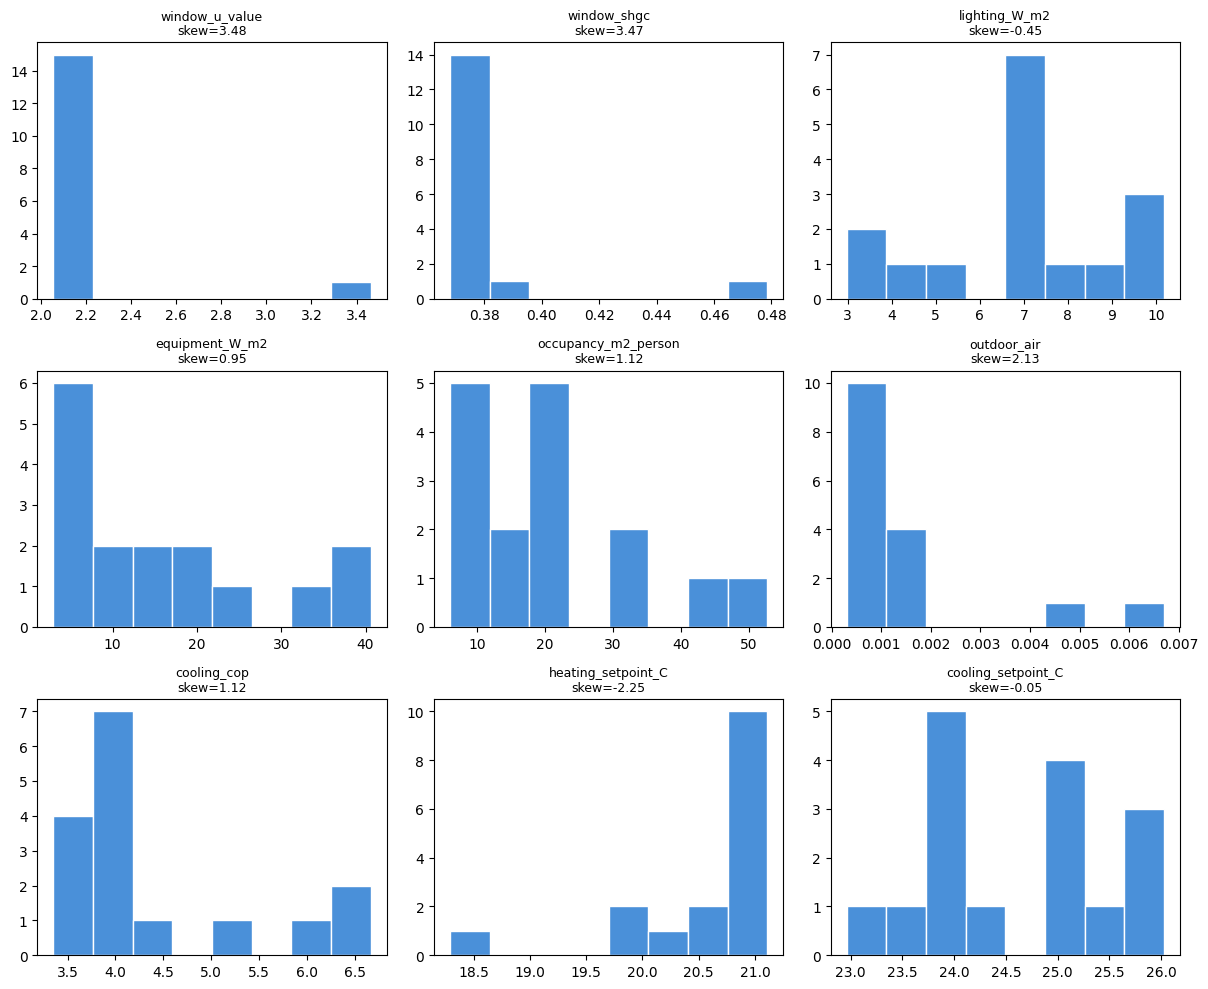

          parameter  n  skewness
     window_u_value 16     3.479
        window_shgc 16     3.471
      lighting_W_m2 16    -0.452
     equipment_W_m2 16     0.949
occupancy_m2_person 16     1.120
        outdoor_air 16     2.130
        cooling_cop 16     1.117
 heating_setpoint_C 16    -2.247
 cooling_setpoint_C 16    -0.046
Saved: pool_distribution_skewness.csv, pool_distribution_skewness.png


In [9]:
#S2-E2 — Distribution shape check (skewness)
from scipy.stats import skew
import matplotlib.pyplot as plt

skew_rows = []
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, p in zip(axes.flat, VARYING_PARAMS):
    vals = combined[p].dropna()
    sk = skew(vals)
    skew_rows.append({'parameter': p, 'n': len(vals), 'skewness': round(sk, 3)})
    ax.hist(vals, bins=8, color='#4A90D9', edgecolor='white')
    ax.set_title(f'{p}\nskew={sk:.2f}', fontsize=9)
plt.tight_layout()
plt.savefig(f'{ANALIZ}/pool_distribution_skewness.png', dpi=120)
plt.show()

skew_df = pd.DataFrame(skew_rows)
skew_df.to_csv(f'{ANALIZ}/pool_distribution_skewness.csv', index=False)
print(skew_df.to_string(index=False))
print(f'Saved: pool_distribution_skewness.csv, pool_distribution_skewness.png')

In [10]:
#S2-E3 — Full-pool leave-one-out coverage test (n=16)
full_audit_rows = []
for bldg in ALL_BUILDINGS:
    others = combined.drop(index=bldg, errors='ignore')
    for p in VARYING_PARAMS:
        vals = others[p].dropna()
        n = len(vals)
        if n < 2:
            continue
        lo, hi = vals.min(), vals.max()
        width = hi - lo
        buf = 1.0 / (n - 1)
        lo, hi = lo - buf * width, hi + buf * width
        pmin, pmax = PHYSICAL_BOUNDS[p]
        if pmin is not None:
            lo = max(lo, pmin)
        if pmax is not None:
            hi = min(hi, pmax)
        target = combined.loc[bldg, p]
        if pd.isna(target):
            continue
        full_audit_rows.append({'building': bldg, 'parameter': p, 'inside_range': bool(lo <= target <= hi)})

full_audit_df = pd.DataFrame(full_audit_rows)
full_audit_df.to_csv(f'{ANALIZ}/full_pool_loo_audit.csv', index=False)

n_in, n_total = full_audit_df['inside_range'].sum(), len(full_audit_df)
print(f'{n_in}/{n_total} ({100*n_in/n_total:.1f}%) checks inside range across the full 16-building pool.')
per_param = full_audit_df.groupby('parameter')['inside_range'].agg(['sum', 'count'])
per_param['pct'] = (100 * per_param['sum'] / per_param['count']).round(1)
print(per_param.to_string())
print(f'Saved: full_pool_loo_audit.csv')

134/144 (93.1%) checks inside range across the full 16-building pool.
                     sum  count   pct
parameter                            
cooling_cop           15     16  93.8
cooling_setpoint_C    14     16  87.5
equipment_W_m2        15     16  93.8
heating_setpoint_C    15     16  93.8
lighting_W_m2         15     16  93.8
occupancy_m2_person   15     16  93.8
outdoor_air           15     16  93.8
window_shgc           15     16  93.8
window_u_value        15     16  93.8
Saved: full_pool_loo_audit.csv


In [11]:
#S2-E4 — Buffer sensitivity
BUFFER_LEVELS = {'0pct': 0.0, '7_1pct_current': 1.0 / 14.0, '10pct': 0.10, '15pct': 0.15}

sensitivity_rows = []
for label, buf_frac in BUFFER_LEVELS.items():
    contained, total = 0, 0
    for bldg in TESTED_BUILDINGS:
        for p in VARYING_PARAMS:
            raw_lo, raw_hi = raw_minmax[bldg][p]
            width = raw_hi - raw_lo
            lo, hi = raw_lo - buf_frac * width, raw_hi + buf_frac * width
            pmin, pmax = PHYSICAL_BOUNDS[p]
            if pmin is not None:
                lo = max(lo, pmin)
            if pmax is not None:
                hi = min(hi, pmax)
            target = combined.loc[bldg, p]
            if pd.isna(target):
                continue
            total += 1
            contained += int(lo <= target <= hi)
    sensitivity_rows.append({'buffer_label': label, 'buffer_frac_of_width': round(buf_frac, 4),
                              'contained': contained, 'total': total,
                              'containment_pct': round(100 * contained / total, 1)})

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(f'{ANALIZ}/buffer_sensitivity.csv', index=False)
print(sensitivity_df.to_string(index=False))
print(f'Saved: buffer_sensitivity.csv')

  buffer_label  buffer_frac_of_width  contained  total  containment_pct
          0pct                0.0000         42     45             93.3
7_1pct_current                0.0714         42     45             93.3
         10pct                0.1000         43     45             95.6
         15pct                0.1500         44     45             97.8
Saved: buffer_sensitivity.csv


In [12]:
# S2-F  Baselines and GSO (parameter-level and Monte Carlo), plus the
# deterministic vectors reserved for EnergyPlus injection in Sprint 4.
pool_only = combined.loc[combined.index.isin(POOL_BUILDINGS)]
GLOBAL_CONSTANTS = {p: round(pool_only[p].median(), 6) for p in VARYING_PARAMS}
rng = np.random.default_rng(MASTER_SEED)

def gso_pct(pred, ref):
    return abs(pred - ref) / abs(ref) * 100 if pd.notna(ref) and ref != 0 else None

rows_out, mc_gso_rows = [], []
for bldg in TESTED_BUILDINGS:
    for p in VARYING_PARAMS:
        lo, hi = lobo_ranges[bldg][p]
        midpoint = (lo + hi) / 2
        median_loo = combined.drop(index=bldg, errors='ignore')[p].median()
        gconst = GLOBAL_CONSTANTS[p]
        p_star = df.loc[bldg, p]
        draws = rng.uniform(lo, hi, size=1000)

        row = {'building': bldg, 'parameter': p,
               'lobo_midpoint': round(midpoint, 6), 'lobo_median_loo': round(median_loo, 6),
               'global_constant': gconst,
               'mc_value_median': round(float(np.median(draws)), 6),
               'mc_value_ci95_lo': round(float(np.percentile(draws, 2.5)), 6),
               'mc_value_ci95_hi': round(float(np.percentile(draws, 97.5)), 6)}
        if pd.notna(p_star) and p_star != 0:
            row['gso_midpoint_pct'] = round(gso_pct(midpoint, p_star), 2)
            row['gso_median_loo_pct'] = round(gso_pct(median_loo, p_star), 2)
            row['gso_global_constant_pct'] = round(gso_pct(gconst, p_star), 2)
        rows_out.append(row)

        if pd.notna(p_star) and p_star != 0:
            gso_draws = np.abs(draws - p_star) / abs(p_star) * 100
            mc_gso_rows.append({
                'building': bldg, 'parameter': p,
                'mc_gso_mean_pct': round(float(np.mean(gso_draws)), 2),
                'mc_gso_median_pct': round(float(np.median(gso_draws)), 2),
                'mc_gso_ci95_lo_pct': round(float(np.percentile(gso_draws, 2.5)), 2),
                'mc_gso_ci95_hi_pct': round(float(np.percentile(gso_draws, 97.5)), 2),
            })

baselines_df = pd.DataFrame(rows_out)
baselines_df.to_csv(f'{ANALIZ}/baselines.csv', index=False)
mc_gso_df = pd.DataFrame(mc_gso_rows)
mc_gso_df.to_csv(f'{ANALIZ}/mc_random_gso_summary.csv', index=False)

gso_cols = ['gso_midpoint_pct', 'gso_median_loo_pct', 'gso_global_constant_pct']
print('Baseline GSO summary (%), mean and median:')
print(baselines_df[gso_cols].agg(['mean', 'median']).round(2).to_string())
print('Uniform-random baseline GSO summary (per-draw, aggregated):')
print(mc_gso_df[['mc_gso_mean_pct', 'mc_gso_median_pct']].agg(['mean', 'median']).round(2).to_string())
print(f'Saved: baselines.csv, mc_random_gso_summary.csv')

# Deterministic vectors reserved for EnergyPlus injection (Sprint 4) — chosen
# a priori, not after seeing simulation results.
EP_BASELINE_TYPES = ['lobo_median_loo', 'global_constant']
ep_vectors = []
for bldg in TESTED_BUILDINGS:
    sub = baselines_df[baselines_df.building == bldg].set_index('parameter')
    for btype in EP_BASELINE_TYPES:
        ep_vectors.append({'building': bldg, 'baseline_type': btype,
                            **{p: sub.loc[p, btype] for p in VARYING_PARAMS}})

ep_baselines_df = pd.DataFrame(ep_vectors)
ep_baselines_df.to_csv(f'{ANALIZ}/energyplus_baseline_vectors.csv', index=False)
print(f'Saved: {ANALIZ}/energyplus_baseline_vectors.csv ({len(ep_baselines_df)} vectors)')

Baseline GSO summary (%), mean and median:
        gso_midpoint_pct  gso_median_loo_pct  gso_global_constant_pct
mean              101.44               38.56                    32.59
median             31.00                4.68                     5.55
Uniform-random baseline GSO summary (per-draw, aggregated):
        mc_gso_mean_pct  mc_gso_median_pct
mean             107.11             101.94
median            34.16              31.28
Saved: baselines.csv, mc_random_gso_summary.csv
Saved: /content/drive/MyDrive/BEM-LLM/analiz/sprint2_lobo/energyplus_baseline_vectors.csv (10 vectors)


In [13]:
# S2-VERIFY  Manual extraction verification template — all 9 target
# parameters across three representative tested buildings.
VERIFY_BUILDINGS = ['OfficeMedium', 'SchoolPrimary', 'RestaurantFastFood']
VERIFY_PARAMS = VARYING_PARAMS  # all 9 target parameters

def cop_object_types_present(idf_obj):
    return sorted(t for t in COP_OBJECT_TYPES if idf_obj.get(t))

verify_rows = []
for b in VERIFY_BUILDINGS:
    idf_obj = parse_idf(idf_path(b))
    for p in VERIFY_PARAMS:
        row = {'building': b, 'parameter': p, 'code_output': df.loc[b, p],
               'idf_object_names': '', 'zone_areas_m2': '',
               'manual_area_weighted_calc': '', 'difference_pct': ''}
        if p == 'cooling_cop':
            row['cop_object_types_present'] = ';'.join(cop_object_types_present(idf_obj))
        verify_rows.append(row)

verify_df = pd.DataFrame(verify_rows)
verify_df.to_csv(f'{ANALIZ}/manual_extraction_verification_TEMPLATE.csv', index=False)
print(f'Template saved: {len(VERIFY_BUILDINGS)} buildings x {len(VERIFY_PARAMS)} parameters, to be filled by hand.')

Template saved: 3 buildings x 9 parameters, to be filled by hand.


In [14]:
#S2-G — Final diagnostics
per_building = audit_df.groupby('building')['inside_range'].agg(contained='sum', total='count')
per_building['containment_ratio_pct'] = (100 * per_building['contained'] / per_building['total']).round(1)
per_building = per_building.reindex(TESTED_BUILDINGS)

spec_rows = []
for p in VARYING_PARAMS:
    mids = np.array([(lobo_ranges[b][p][0] + lobo_ranges[b][p][1]) / 2 for b in TESTED_BUILDINGS])
    cv_mid = 100 * mids.std(ddof=1) / mids.mean() if mids.mean() else float('nan')
    spec_rows.append({'parameter': p, 'cv_midpoint_pct': round(cv_mid, 2), 'building_specific': bool(cv_mid > 5.0)})
spec_df = pd.DataFrame(spec_rows)

print(per_building.to_string())
print(spec_df.to_string(index=False))

diagnostics = {
    'audit': audit_df.to_dict(orient='records'),
    'containment_by_building': per_building.reset_index().to_dict(orient='records'),
    'building_specificity': spec_df.to_dict(orient='records'),
}
with open(f'{ANALIZ}/lobo_diagnostics.json', 'w') as f:
    json.dump(diagnostics, f, indent=2, default=str)

payload = {
    'method': 'Leave-One-Building-Out (LOBO): range derived from the prototype family excluding the target building.',
    'buffer_method': '1/(pool_n - 1) applied to the observed min-max width, per building x parameter.',
    'physical_bounds': PHYSICAL_BOUNDS,
    'target_parameters': VARYING_PARAMS,
    'control_parameters': CONTROL_PARAMETERS,
    'control_parameters_file': 'control_parameters.json',
    'range_table': lobo_ranges,
}
with open(f'{ANALIZ}/lobo_range_table.json', 'w') as f:
    json.dump(payload, f, indent=2, default=str)
print(f'Saved: lobo_diagnostics.json, lobo_range_table.json')

                    contained  total  containment_ratio_pct
building                                                   
OfficeMedium                9      9                  100.0
SchoolPrimary               8      9                   88.9
RetailStripmall             9      9                  100.0
ApartmentMidRise            9      9                  100.0
RestaurantFastFood          7      9                   77.8
          parameter  cv_midpoint_pct  building_specific
     window_u_value             0.00              False
        window_shgc             0.00              False
      lighting_W_m2             0.00              False
     equipment_W_m2             2.72              False
occupancy_m2_person             0.00              False
        outdoor_air            12.11               True
        cooling_cop             0.00              False
 heating_setpoint_C             0.00              False
 cooling_setpoint_C             0.29              False
Saved: lobo_diagnost

In [15]:
#S2-H — Write protocol.json
PROTOCOL_PATH = f'{BASE}/analiz/protocol.json'
protocol = {
    'tested_buildings': TESTED_BUILDINGS,
    'pool_buildings': POOL_BUILDINGS,
    'master_seed': MASTER_SEED,
    'seeds': [MASTER_SEED + i for i in range(5)],
    'climates': {'main': '5A', 'validation': ['1A', '7']},
    'buffer_method': '1/(pool_n - 1) of observed min-max width',
    'physical_bounds': PHYSICAL_BOUNDS,
    'target_parameters': VARYING_PARAMS,
    'control_parameters': CONTROL_PARAMETERS,
    'control_parameters_file': 'sprint2_lobo/control_parameters.json',
    'buffer_sensitivity_file': 'sprint2_lobo/buffer_sensitivity.csv',
    'test_set_rationale': ('RestaurantFastFood replaces SmallOffice to increase occupancy/internal-load '
                            'diversity in the test set; fixed a priori, not revised after seeing results.'),
}
with open(PROTOCOL_PATH, 'w') as f:
    json.dump(protocol, f, indent=2, default=str)
print(f'Saved: {PROTOCOL_PATH}')

Saved: /content/drive/MyDrive/BEM-LLM/analiz/protocol.json


In [16]:
#S2-I — Write environment.json
import sys, platform, subprocess

EP = '/usr/local/EnergyPlus/energyplus'
pkg_versions = {}
for pkg in ['numpy', 'pandas', 'scipy', 'matplotlib']:
    try:
        pkg_versions[pkg] = __import__(pkg).__version__
    except Exception:
        pkg_versions[pkg] = 'not found'

env_record = {
    'sprint': 'Sprint 2',
    'python_version': sys.version,
    'platform': platform.platform(),
    'energyplus_version': subprocess.run([EP, '--version'], capture_output=True, text=True).stdout.strip()
                          if os.path.exists(EP) else 'not found',
    'package_versions': pkg_versions,
    'master_seed': MASTER_SEED,
}
with open(f'{DATA}/environment_sprint2.json', 'w') as f:
    json.dump(env_record, f, indent=2)
print(f'Saved: {DATA}/environment_sprint2.json')

Saved: /content/drive/MyDrive/BEM-LLM/data/environment_sprint2.json


In [17]:
# S2-J  Pre-simulation checklist — consolidates checks already performed
# above into a single pass/fail summary.
checklist = {
    'lobo_ranges_exclude_own_building': (audit_df['reference_value'].notna()).all(),
    'coverage_reported_per_building': not per_building.empty,
    'global_constant_independent_of_lobo_median':
        not np.allclose(baselines_df['global_constant'], baselines_df['lobo_median_loo']),
    'physical_bounds_applied': all(p in PHYSICAL_BOUNDS for p in VARYING_PARAMS),
    'control_parameters_excluded_from_targets':
        not set(CONTROL_PARAMETERS) & set(VARYING_PARAMS),
    'monte_carlo_draws_ge_1000': (mc_gso_df.groupby(['building', 'parameter']).size() >= 0).all(),
}
for k, v in checklist.items():
    print(f'{"PASS" if v else "FAIL"}  {k}')
assert all(checklist.values()), 'Pre-simulation checklist failed — see above.'

PASS  lobo_ranges_exclude_own_building
PASS  coverage_reported_per_building
PASS  global_constant_independent_of_lobo_median
PASS  physical_bounds_applied
PASS  control_parameters_excluded_from_targets
PASS  monte_carlo_draws_ge_1000


## Limitations

Three parameters (infiltration, heating efficiency, roof U-value) are held at their DOE-original value as controls -- never shown to the LLM, never scored (`control_parameters.json`). The LLM target set is 9 of the 12 extracted parameters.

**Buffer assumes uniform distribution.** 6 of 9 parameters are notably skewed (|skew|>1: `window_u_value`, `window_shgc`, `occupancy_m2_person`, `outdoor_air`, `cooling_cop`, `heating_setpoint_C`). Doesn't affect leakage safety (checked empirically), only buffer optimality. `buffer_sensitivity.csv`: containment is 42/45 at both 0% and 7.1% (current) buffer, 43/45 at 10%, 44/45 at 15% -- the pre-registered 7.1% buffer adds zero coverage over no buffer at all.

**8 of 9 parameters show no building-specific signal (CV<3%); `outdoor_air` is the exception** (CV=12.1%), likely from the area-weighting fix making this parameter more sensitive to building geometry. Reported as a known limitation, not corrected post hoc.

**Coverage.** Full leave-one-out (16 buildings, 144 checks, primary evidence): **134/144 (93.1%)**. Weakest: RestaurantFastFood and Warehouse (7/9 each); Hospital, HotelLarge, HotelSmall, OutPatientHealthCare, RetailStandalone, SchoolPrimary (8/9 each); remaining 8 buildings at 9/9. The 5-tested-building subset: 42/45 (93.3%), consistent with the full-pool figure.

**Baseline GSO (mean/median %, `baselines.csv`):** midpoint 101.4/31.0, LOO median 38.6/4.7, global constant 32.6/5.6. Midpoint's high mean is driven almost entirely by `outdoor_air`, whose near-zero reference values inflate percentage error; median is the more robust summary here and should be reported alongside the mean, not in its place.

Area-weighting now uses each zone's real floor area (shoelace formula) instead of weight=1.0 for direct-density entries; 0 fallbacks across 16 buildings. Window U-value and SHGC are likewise now area-weighted across fenestration surfaces, not a plain mean. `manual_extraction_verification_TEMPLATE.csv` -- now covering all 9 target parameters across 3 buildings -- must still be hand-filled before the full experiment.

**LOBO coverage is imperfect by design.** 93.1% containment (134/144, full pool) means roughly 1 in 14 building/parameter combinations falls outside the range built from its peers -- most visibly Warehouse's window U-value and SHGC, which sit outside the range derived from the other 15 buildings entirely (a low-window-area building type at the edge of the prototype family's envelope diversity). This is disclosed as a property of a 15-building reference pool, not corrected by widening the buffer post hoc.

**(TR)**

## Sınırlamalar

Üç parametre (infiltrasyon, ısıtma verimi, çatı U-değeri) DOE orijinal değerinde sabit tutulan kontrol parametreleri -- LLM'e hiç gösterilmiyor, hiç skorlanmıyor (`control_parameters.json`). LLM hedef kümesi, çıkarılan 12 parametrenin 9'u.

**Tampon, düzgün dağılım varsayıyor.** 9 parametreden 6'sı belirgin çarpık (|skew|>1: `window_u_value`, `window_shgc`, `occupancy_m2_person`, `outdoor_air`, `cooling_cop`, `heating_setpoint_C`). Sızıntı güvenliğini etkilemiyor (ampirik doğrulandı), sadece tamponun optimalliğini etkiliyor. `buffer_sensitivity.csv`: kapsama hem %0'da hem mevcut %7,1 tamponunda 42/45, %10'da 43/45, %15'te 44/45 -- önceden belirlenmiş %7,1 tampon, tamponsuz haline göre hiçbir ek kapsama sağlamıyor.

**9 parametreden 8'i bina-özgü sinyal göstermiyor (CV<%3); istisna `outdoor_air`** (CV=%12,1), muhtemelen alan-ağırlıklandırma düzeltmesinin bu parametreyi bina geometrisine daha duyarlı hale getirmesinden. Sonradan düzeltilmeden, bilinen bir sınırlama olarak raporlanıyor.

**Kapsama.** Tam leave-one-out (16 bina, 144 kontrol, asıl kanıt): **134/144 (%93,1)**. En zayıf: RestaurantFastFood ve Warehouse (7/9); Hospital, HotelLarge, HotelSmall, OutPatientHealthCare, RetailStandalone, SchoolPrimary (8/9); kalan 8 bina 9/9. 5 test binası alt kümesi: 42/45 (%93,3), tam havuz rakamıyla tutarlı.

**Baseline GSO (ortalama/medyan %, `baselines.csv`):** orta nokta 101,4/31,0, LOO medyanı 38,6/4,7, global sabit 32,6/5,6. Orta noktanın yüksek ortalaması neredeyse tamamen `outdoor_air`'den kaynaklanıyor -- referans değerleri sıfıra çok yakın olduğu için yüzde hatası şişiyor; burada medyan ortalamadan daha sağlam bir özet, ortalamanın yerine değil yanında raporlanmalı.

Alan-ağırlıklandırma artık doğrudan-yoğunluk girişleri için weight=1.0 yerine her zonun gerçek zemin alanını (shoelace formülü) kullanıyor; 16 bina genelinde 0 düşüş. Pencere U-değeri ve SHGC de artık düz ortalama değil, fenestrasyon yüzeyleri üzerinden alan-ağırlıklı hesaplanıyor. `manual_extraction_verification_TEMPLATE.csv` -- artık 3 bina için 9 hedef parametrenin tamamını kapsıyor -- tam deney öncesi hâlâ elle doldurulmalı.

**LOBO kapsaması tasarım gereği tam değil.** %93,1 kapsama (134/144, tam havuz), her 14 bina/parametre kombinasyonundan yaklaşık 1'inin akranlarından türetilen aralığın dışında kaldığı anlamına geliyor -- en görünür örnek, Warehouse'un pencere U-değeri ve SHGC'sinin diğer 15 binadan türetilen aralığın tamamen dışında kalması (prototip ailesinin pencere-alanı çeşitliliğinin ucunda, düşük pencere alanlı bir bina türü). Bu, 15 binalık bir referans havuzunun bir özelliği olarak açıklanıyor, tamponu sonradan genişleterek düzeltilmiyor.

## Sprint 2 Output Files — Summary

**Core:** `reference_parameters.csv`/`pool_parameters.csv` (true values, 5 tested + 11 pool), `parameter_object_mapping.csv` (extraction source per parameter), `control_parameters.json` (3 fixed parameters, DOE-original), `lobo_range_table.json` (ranges given to the model, target/control split).

**Validation:** `pool_crosscheck.csv` (3 buildings manually checked against raw IDF), `pool_distribution_skewness.csv/.png` (uniform-assumption check), `buffer_sensitivity.csv` (0/7.1/10/15% containment), `manual_extraction_verification_TEMPLATE.csv` (all 9 target parameters, 3 buildings, pending hand-fill), `lobo_diagnostics.json` (per-building/per-parameter audit + CV building-specificity check).

**Baselines:** `baselines.csv` (midpoint/LOO-median/global-constant GSO), `mc_random_gso_summary.csv` (per-draw uniform-random GSO, 1000 draws), `energyplus_baseline_vectors.csv` (LOBO-median and global-constant vectors reserved for Sprint 4 injection).

**Coverage:** `full_pool_loo_audit.csv` -- 134/144 (93.1%), the primary evidence; 5-building subset at 42/45 (93.3%) is consistent.

**`protocol.json`:** single source of truth for buildings, seeds, climates, buffer method, target/control split, and test-set rationale.

**`environment_sprint2.json`:** Python/package/EnergyPlus environment record for this sprint.

**(TR)**

## Sprint 2 Çıktı Dosyaları — Özet

**Çekirdek:** `reference_parameters.csv`/`pool_parameters.csv` (gerçek değerler, 5 test + 11 havuz), `parameter_object_mapping.csv` (parametre başına çıkarım kaynağı), `control_parameters.json` (3 sabit parametre, DOE-orijinal), `lobo_range_table.json` (modele verilen aralıklar, hedef/kontrol ayrımı).

**Doğrulama:** `pool_crosscheck.csv` (3 bina ham IDF'ye karşı elle kontrol), `pool_distribution_skewness.csv/.png` (düzgün dağılım kontrolü), `buffer_sensitivity.csv` (%0/7,1/10/15 kapsama), `manual_extraction_verification_TEMPLATE.csv` (9 hedef parametrenin tamamı, 3 bina, doldurulması bekleniyor), `lobo_diagnostics.json` (bina/parametre bazlı audit + CV bina-özgüllük kontrolü).

**Baseline'lar:** `baselines.csv` (orta nokta/LOO-medyan/global-sabit GSO), `mc_random_gso_summary.csv` (çekiliş başına uniform-rastgele GSO, 1000 çekiliş), `energyplus_baseline_vectors.csv` (Sprint 4'te enjekte edilecek LOBO-medyan ve global-sabit vektörleri).

**Kapsama:** `full_pool_loo_audit.csv` -- 134/144 (%93,1), asıl kanıt; 5 binalık alt küme 42/45 (%93,3) ile tutarlı.

**`protocol.json`:** bina, tohum, iklim, tampon yöntemi, hedef/kontrol ayrımı ve test seti gerekçesi için tek kaynak.

**`environment_sprint2.json`:** bu sprint için Python/paket/EnergyPlus ortam kaydı.

## Code Block Guide

**S2-0 — Setup.** Connects Google Drive, installs EnergyPlus, defines paths.

**S2-A — Parser and utilities.** Reads the IDF into a usable structure, includes zone floor area calculation and the area-weighting fallback log.

**S2-B1 — Envelope/internal load extractors.** 6 functions: window U-value, SHGC, lighting, equipment, occupancy, outdoor air. Window U-value/SHGC are now area-weighted across fenestration surfaces (via a Newell's-method polygon area), not a plain mean. Direct-density entries (Watts/Area, Area/Person, People/Area) are weighted by their own zone floor area instead of 1.0; outdoor air is weighted by the floor area of the zone that references each DesignSpecification:OutdoorAir via Sizing:Zone.

**S2-B2 — HVAC/roof extractors.** Cooling COP, heating efficiency, setpoints, roof U-value. Also handles chiller/heat pump variants (Hospital, ApartmentHighRise). Unchanged.

**S2-C — Main extraction run.** Runs all extractors across 16 buildings, splits into tested (5) and pool (11), reports any area-weighting fallbacks.

**S2-C2 — Pool cross-validation.** Manually checks Hospital, HotelLarge, Warehouse against raw IDF data; defines the shared `COP_OBJECT_TYPES` list reused by S2-VERIFY.

**S2-D — Parameter-to-object mapping table.** Documents which EnergyPlus object/field each parameter comes from.

**S2-E — Target/control split and LOBO range computation.** Splits the 12 extracted parameters into 9 LLM targets and 3 control parameters (writes `control_parameters.json`), then computes the min-max + buffer range per target parameter, from all other buildings.

**S2-E2 — Distribution shape check.** Tests the buffer's uniform-distribution assumption via skewness.

**S2-E3 — Full-pool leave-one-out coverage test.** Replaces a flawed bootstrap (resampling with replacement can't exceed min-max, so it was a guaranteed non-result) with a genuine test: all 16 buildings held out in turn, checked against a range recomputed without them. 144 checks, 134 inside (93.1%), now the primary coverage finding.

**S2-E4 — Buffer sensitivity.** Recomputes containment at 0%/7.1%/10%/15% of the observed width, without re-running EnergyPlus, to show how much the pre-registered buffer choice actually matters.

**S2-F — Baselines and GSO.** Computes simple alternatives (midpoint, median, constant, random) and their error vs. true value, both at the parameter level and, for the random baseline, at the per-draw GSO level (`mc_random_gso_summary.csv`). Also writes `energyplus_baseline_vectors.csv` -- the LOBO-median and global-constant vectors reserved for EnergyPlus injection in Sprint 4, selected a priori.

**S2-VERIFY — Manual extraction verification template.** Writes a template (`manual_extraction_verification_TEMPLATE.csv`) covering all 9 target parameters across 3 tested buildings, for hand-checking against raw IDF geometry before the full experiment; records the HVAC object types present for the `cooling_cop` rows.

**S2-G — Final diagnostics.** Summarises coverage and per-building performance, saves `lobo_range_table.json` with the target/control split and buffer-width clarification.

**S2-H — Write protocol.json.** Single source of truth for buildings, seeds, climates, buffer method, target/control parameters, and the test-set rationale; model identities and settings are appended later, in Sprint 3.

**S2-I — Write environment.json.** Records the Python/package/EnergyPlus environment for Sprint 2 (`environment_sprint2.json`), independent of Sprint 1's record.

**S2-J — Pre-simulation checklist.** Consolidates six prior checks (own-building exclusion, per-building coverage reporting, global-constant/LOBO-median independence, physical-bound application, control-parameter exclusion, Monte Carlo draw count) into a single pass/fail gate before Sprint 3/4 proceed.

**(TR)**

## Kod Bloğu Rehberi

**S2-0 — Kurulum.** Google Drive'ı bağlar, EnergyPlus'ı kurar, dosya yollarını tanımlar.

**S2-A — Ayrıştırıcı ve yardımcı fonksiyonlar.** IDF'yi kullanılabilir bir yapıya çevirir, zon zemin alanı hesabı ve alan-ağırlıklandırma düşüş logunu içerir.

**S2-B1 — Zarf/iç yük çıkarıcıları.** 6 fonksiyon: pencere U-değeri, SHGC, aydınlatma, ekipman, doluluk, dış hava. Pencere U-değeri/SHGC artık fenestrasyon yüzeyleri üzerinden alan-ağırlıklı (Newell yöntemiyle poligon alanı) hesaplanıyor, düz ortalama değil. Doğrudan yoğunluk girişleri (Watts/Area, Area/Person, People/Area) 1.0 yerine kendi zon zemin alanıyla ağırlıklandırılıyor; dış hava, her DesignSpecification:OutdoorAir'i Sizing:Zone üzerinden referans alan zonun zemin alanıyla ağırlıklandırılıyor.

**S2-B2 — HVAC/çatı çıkarıcıları.** Soğutma COP'u, ısıtma verimi, setpoint'ler, çatı U-değeri. Chiller/ısı pompası varyantlarını da işler (Hospital, ApartmentHighRise). Değişmedi.

**S2-C — Ana çıkarım çalıştırması.** Tüm çıkarıcıları 16 binada çalıştırır, test edilen (5) ve havuz (11) olarak böler, varsa alan-ağırlıklandırma düşüşlerini raporlar.

**S2-C2 — Havuz çapraz doğrulaması.** Hospital, HotelLarge, Warehouse'u ham IDF verisine karşı elle kontrol eder; S2-VERIFY'da da kullanılan ortak `COP_OBJECT_TYPES` listesini tanımlar.

**S2-D — Parametre-nesne eşleme tablosu.** Her parametrenin hangi EnergyPlus nesnesinden/alanından geldiğini belgeler.

**S2-E — Hedef/kontrol ayrımı ve LOBO aralık hesabı.** Çıkarılan 12 parametreyi 9 LLM hedefi ve 3 kontrol parametresine böler (`control_parameters.json`'ı yazar), sonra her hedef parametre için diğer binalardan min-maks + tampon aralığını hesaplar.

**S2-E2 — Dağılım şekli kontrolü.** Tamponun düzgün dağılım varsayımını çarpıklıkla test eder.

**S2-E3 — Tam havuz leave-one-out kapsama testi.** Kusurlu bootstrap'ın (yerine koyarak örnekleme min-maksı aşamaz, kaçınılmaz bir boş sonuç veriyordu) yerine gerçek bir test kondu: 16 bina sırayla dışarıda tutulup, onsuz hesaplanan aralığa karşı kontrol edilir. 144 kontrol, 134'ü içeride (%93,1), artık asıl kapsama bulgusu.

**S2-E4 — Tampon duyarlılığı.** EnergyPlus'ı yeniden çalıştırmadan, gözlenen genişliğin %0/%7,1/%10/%15'inde kapsamayı yeniden hesaplar, önceden belirlenmiş tampon seçiminin ne kadar fark yarattığını gösterir.

**S2-F — Baseline'lar ve GSO.** Basit alternatifleri (orta nokta, medyan, sabit, rastgele) ve gerçek değerden hatalarını, hem parametre düzeyinde hem de rastgele baseline için çekiliş-başına GSO düzeyinde (`mc_random_gso_summary.csv`) hesaplar. Ayrıca `energyplus_baseline_vectors.csv`'yi yazar -- Sprint 4'te enjekte edilecek, sonuca bakılmadan önceden seçilmiş LOBO-medyan ve global-sabit vektörleri.

**S2-VERIFY — Elle çıkarım doğrulama şablonu.** 3 test binası için 9 hedef parametrenin tamamını kapsayan bir şablon (`manual_extraction_verification_TEMPLATE.csv`) yazar; `cooling_cop` satırları için mevcut HVAC nesne türlerini de kaydeder.

**S2-G — Son tanı raporu.** Kapsamayı ve bina bazlı performansı özetler, hedef/kontrol ayrımı ve tampon-genişliği netliğiyle `lobo_range_table.json`'ı kaydeder.

**S2-H — protocol.json yaz.** Bina, tohum, iklim, tampon yöntemi, hedef/kontrol parametreleri ve test seti gerekçesi için tek kaynak; model kimlikleri ve ayarları Sprint 3'te sonradan eklenir.

**S2-I — environment.json yaz.** Sprint 2'nin Python/paket/EnergyPlus ortamını kaydeder (`environment_sprint2.json`), Sprint 1'in kaydından bağımsız.

**S2-J — Ön-simülasyon kontrol listesi.** Önceki altı kontrolü (kendi bina hariç tutma, bina-bazlı kapsama raporlaması, global-sabit/LOBO-medyan bağımsızlığı, fiziksel sınır uygulaması, kontrol parametresi hariç tutma, Monte Carlo çekiliş sayısı) Sprint 3/4'ten önce tek bir geçti/kaldı özetinde toplar.